# Coverage and SQD energies based on AerSimulator plaquette-circuit simulations

In [1]:
import os
from concurrent.futures import ThreadPoolExecutor
import tempfile
import numpy as np
from scipy.sparse.linalg import eigsh
import h5py
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding

from qiskit_aer import AerSimulator
from qiskit_addon_sqd.qubit import project_operator_to_subspace
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.circuits import make_plaquette_circuits, compose_trotter_circuits
from skqd_z2lgt.sqd import keys_to_intset, qiskit_sqd
from skqd_z2lgt.ising_hamiltonian import ising_hamiltonian, make_matvec, parse_hamiltonian
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
from skqd_z2lgt.ising_dmrg import ising_dmrg, get_mps_coverage

os.environ['CUDA_VISIBLE_DEVICES'] = '1,2,3,4,5,6,7'
#os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3'
#os.environ['CUDA_VISIBLE_DEVICES'] = ''
jax.config.update('jax_enable_x64', True)
data_dir = '/data/iiyama/2dz2'

julia_bin = ['julia', '--sysimage', '/opt/julia/iiyama/sysimages/sys_itensors.so']

In [2]:
num_plaquettes = [8, 16, 24, 32]
max_steps = 12
shots = 100_000
num_experiments = 5
couplings = np.array([0.5, 1., 1.5])
dtvals = np.linspace(0.1, 0.7, 7)

In [3]:
def dmrg(hamiltonian):
    with tempfile.NamedTemporaryFile() as tfile:
        dmrg_file = tfile.name

    energy = ising_dmrg(hamiltonian, dmrg_file, julia_bin)
    return dmrg_file, energy

def sqd(bitstring_matrix, hamiltonian, device_id=0):
    with jax.default_device(jax.devices()[device_id]):
        ham_proj = project_operator_to_subspace(bitstring_matrix, hamiltonian)
    evals, _ = eigsh(ham_proj, k=1, which='SA')
    return evals[0]

In [4]:
executor = ThreadPoolExecutor()

dmrg_energies = {}
coverages = {}

for npl in num_plaquettes:
    filename = f'{data_dir}/plaqsim_data/'
    filename += f'{npl}plaqs_{max_steps}steps_{shots}shots.h5'
    try:
        with h5py.File(filename, 'r') as source:
            dmrg_energies[npl] = source['dmrg_energies'][()]
            coverages[npl] = source['coverages'][()]
    except (FileNotFoundError, KeyError):
        pass
    else:
        continue

    samples_filename = f'{data_dir}/plaqsim_data/'
    samples_filename += f'{npl}plaqs_{max_steps}steps_{shots}shots_samples.h5'
    with h5py.File(samples_filename, 'r') as source:
        config = source['lattice_config'][()].decode()
        couplings = source['couplings'][()]
        dtvals = source['dtvals'][()]

    dual_lattice = TriangularZ2Lattice(config).plaquette_dual()

    futures = []
    hamiltonians = []
    for icp, coupling in enumerate(couplings):
        hamiltonian = dual_lattice.make_hamiltonian(coupling)
        futures.append(executor.submit(dmrg, hamiltonian))
        hamiltonians.append(hamiltonian)

    dmrg_energies[npl] = np.empty_like(couplings)
    dmrg_files = []
    for icp, future in enumerate(futures):
        dmrg_file, energy = future.result()
        dmrg_energies[npl][icp] = energy
        dmrg_files.append(dmrg_file)

    print(dmrg_files)

    futures = {}
    for icp in range(len(couplings)):
        for idt in range(len(dtvals)):
            for istep in range(max_steps):
                for iexp in range(num_experiments):
                    future = executor.submit(get_mps_coverage, dmrg_files[icp], samples_filename,
                                             icp, idt, istep, iexp, julia_bin=julia_bin)
                    futures[(icp, idt, istep, iexp)] = future

    coverages[npl] = np.empty((couplings.shape[0], dtvals.shape[0], max_steps, num_experiments))
    for (icp, idt, istep, iexp), future in futures.items():
        coverages[npl][icp, idt, istep, iexp] = future.result()

    for dmrg_file in dmrg_files:
        os.unlink(dmrg_file)

    # futures = {}
    # with h5py.File(samples_filename, 'r') as source:
    #     device_id = 0
    #     for icp, coupling in enumerate(couplings):
    #         for idt in range(len(dtvals)):
    #             for iexp in range(num_experiments):
    #                 for istep in range(max_steps):
    #                     subspace = source[f'c{icp}/dt{idt}/step{istep + 1}/exp{iexp}'][()]
    #                     futures[(icp, idt, iexp, istep)] = executor.submit(
    #                         sqd, subspace, hamiltonians[icp], device_id=device_id
    #                     )
    #                     device_id += 1
    #                     device_id %= jax.device_count()

    # sqd_energies = np.empty_like(coverages)
    # for (icp, idt, iexp, istep), future in futures.items():
    #     sqd_energies[icp, idt, istep, iexp] = future.result()

    with h5py.File(filename, 'w') as out:
        out.create_dataset('lattice_config', data=config)
        out.create_dataset('max_steps', data=max_steps)
        out.create_dataset('shots', data=shots)
        out.create_dataset('num_experiments', data=num_experiments)
        out.create_dataset('couplings', data=couplings)
        out.create_dataset('dtvals', data=dtvals)
        out.create_dataset('dmrg_energies', data=dmrg_energies[npl])
        # out.create_dataset('sqd_energies', data=sqd_energies)
        out.create_dataset('coverages', data=coverages[npl])

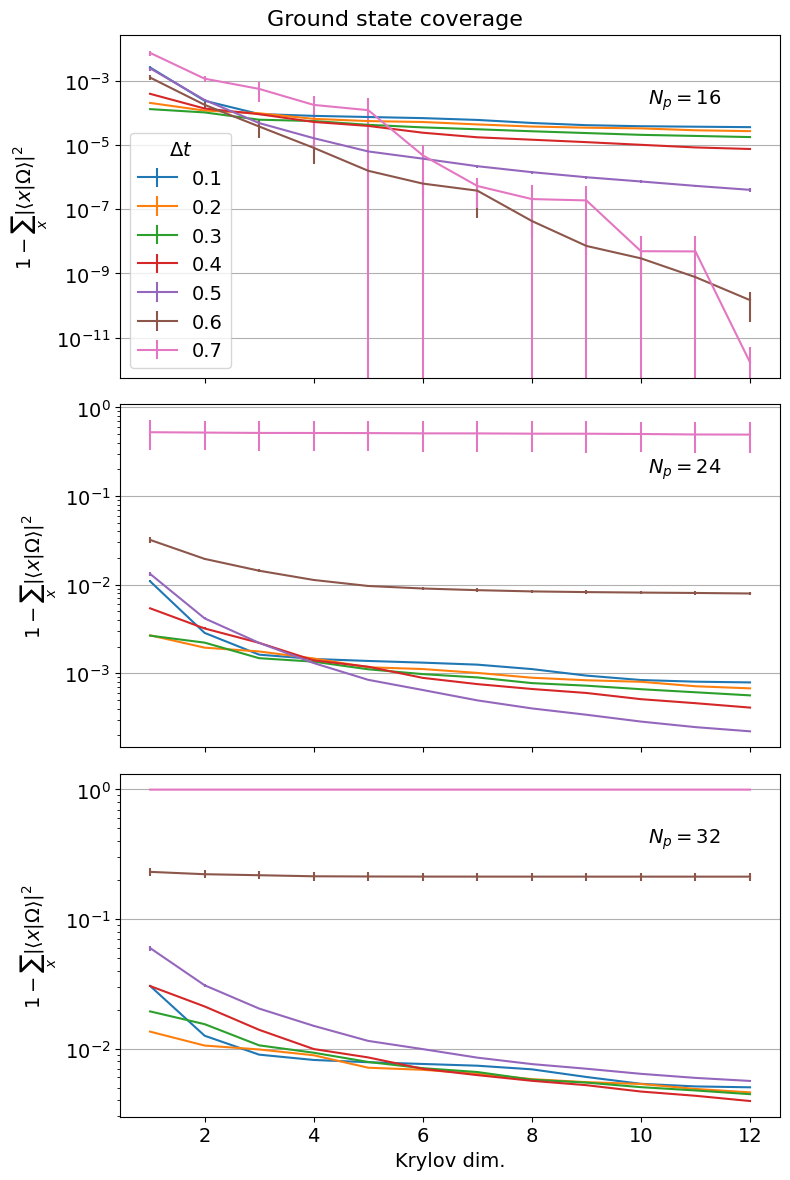

In [29]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)
icp = 1
fig.suptitle(f'Ground state coverage', fontsize=16)

for npl, ax in zip([16, 24, 32], axs):
    for idt, dtval in enumerate(dtvals):
        ax.errorbar(np.arange(1, max_steps + 1), 1. - np.mean(coverages[npl][icp, idt], axis=-1),
                    yerr=np.std(coverages[npl][icp, idt], axis=-1), label=f'{dtval}')

    ax.text(0.8, 0.8, f'$N_p={npl}$', transform=ax.transAxes, fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_ylabel(r'$1 - \sum_{x} |\langle x | \Omega \rangle|^2$', fontsize=14)
    ax.set_yscale('log')
    ax.grid(axis='y')

axs[0].legend(fontsize=14, title=r'$\Delta t$', title_fontsize=14)
axs[2].set_xlabel('Krylov dim.', fontsize=14)

fig.tight_layout()

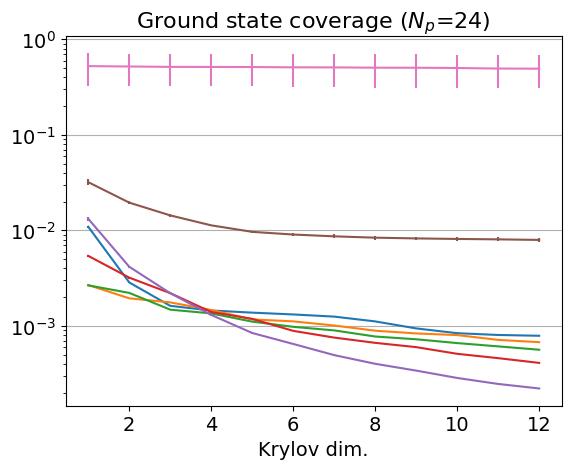

In [ ]:

#plt.legend(fontsize=14, title=r'$\Delta t$', title_fontsize=14);

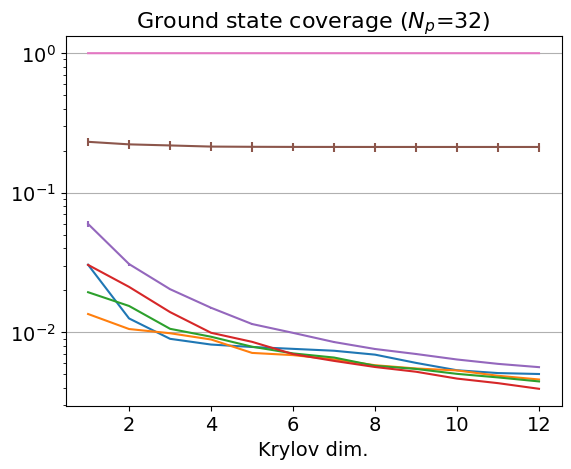

In [9]:
icp = 1
npl = 32
for idt, dtval in enumerate(dtvals):
    plt.errorbar(np.arange(1, max_steps + 1), 1. - np.mean(coverages[npl][icp, idt], axis=-1),
                 yerr=np.std(coverages[npl][icp, idt], axis=-1), label=f'{dtval}')
plt.title(f'Ground state coverage ($N_p$={npl})', fontsize=16)
plt.xlabel('Krylov dim.', fontsize=14)
plt.xticks(fontsize=14)
#plt.ylabel(r'$1 - \sum_{x} |\langle x | \Omega \rangle|^2$', fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.grid(axis='y')
#plt.legend(fontsize=14, title=r'$\Delta t$', title_fontsize=14);

In [7]:
np.mean(coverages[16][1, :, 7], axis=-1)

array([0.99995175, 0.99996267, 0.99997338, 0.99998547, 0.99999858,
       0.99999996, 0.99999979])

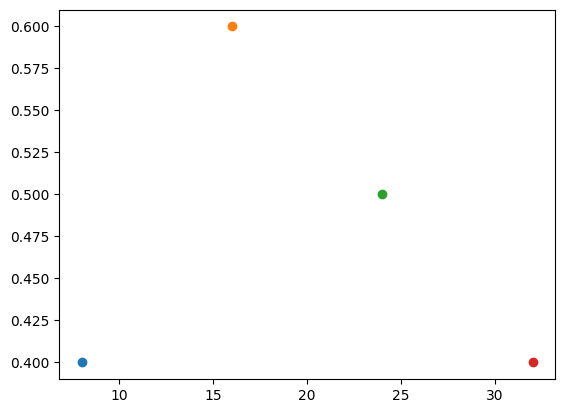

In [8]:
for npl in num_plaquettes:
    plt.scatter([npl], dtvals[np.argmax(np.mean(coverages[npl][1, :, 7], axis=-1))])

In [ ]:
filename = f'{data_dir}/plaqsim_data/'
filename += f'{npl}plaqs_{max_steps}steps_{shots}shots_samples.h5'

with h5py.File(filename, 'r') as source:
    subspace = source[f'c0/dt0/step1/exp0'][()]


(168, 16)


In [14]:
from qiskit_addon_sqd.qubit import matrix_elements_from_pauli

for i, pauli in enumerate(hamiltonians[0].paulis):
    coefficient = hamiltonians[0].coeffs[i]
    matrix_elements, row_coords, col_coords = matrix_elements_from_pauli(
        subspace, pauli
    )
    print(matrix_elements, row_coords, col_coords)
# ham_proj = project_operator_to_subspace(subspace, hamiltonians[0])

[ 1.+0.j -1.+0.j  1.+0.j -1.+0.j  1.+0.j -1.+0.j  1.+0.j  1.+0.j -1.+0.j
  1.+0.j  1.+0.j  1.+0.j  1.+0.j -1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j
 -1.+0.j  1.+0.j -1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j -1.+0.j
  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j -1.+0.j
  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42] [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25 157 157 157 157 157 157 157 157 157 168
 168 168 168 168 168 168 168]
[ 1.+0.j -1.+0.j  1.+0.j -1.+0.j  1.+0.j -1.+0.j  1.+0.j  1.+0.j -1.+0.j
  1.+0.j  1.+0.j  1.+0.j  1.+0.j -1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j
 -1.+0.j  1.+0.j -1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j -1.+0.j
  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j -1.+0.j
  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  1.+0.j  

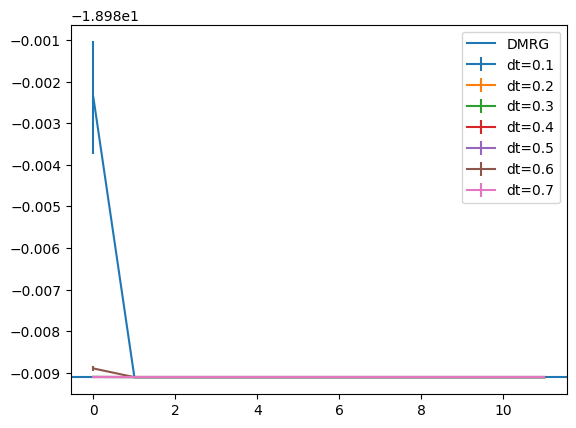

In [6]:
for idt, dt in enumerate(dtvals):
    plt.errorbar(np.arange(max_steps), np.mean(sqd_energies[2, idt], axis=-1), yerr=np.std(sqd_energies[2, idt], axis=-1), label=f'dt={dt}')
plt.axhline(dmrg_energies[2], label='DMRG')
plt.legend();

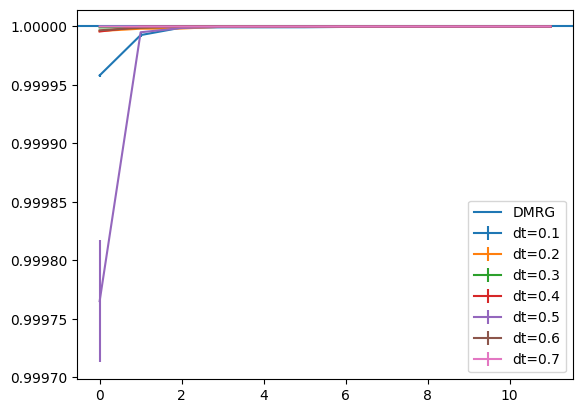

In [7]:
for idt, dt in enumerate(dtvals):
    plt.errorbar(np.arange(max_steps), np.mean(coverages[0, idt], axis=-1), yerr=np.std(coverages[0, idt], axis=-1), label=f'dt={dt}')
plt.axhline(1., label='DMRG')
plt.legend();

In [ ]:
with tempfile.NamedTemporaryFile() as tfile:
    dmrg_file = tfile.name

dual_lattice = TriangularZ2Lattice(configs[0]).plaquette_dual

ising_dmrg(hamiltonian)